k     t       Y numerical     Y exact
0 1.0
1 0.9432392120361328
2 0.8974907520860143
0 1.0
1 0.9432392120361328
2 0.8974907520860143
0 1.0
1 0.9432392120361328
2 0.8974907520860143
  0 0.000 1.00000000000 1.00000000000
  1 0.125 0.94323921204 0.94323918844
  2 0.250 0.89749075209 0.89749070775
  3 0.375 0.86208741701 0.86208735454
  4 0.500 0.83640232328 0.83640234921
  5 0.625 0.81984678392 0.81984688684
  6 0.750 0.81186766577 0.81186783637
  7 0.875 0.81194534953 0.81194557928
  8 1.000 0.81959169802 0.81959197914
  9 1.125 0.83434814878 0.83434847419
 10 1.250 0.85578392225 0.85578428556
 11 1.375 0.88349433850 0.88349473391
 12 1.500 0.91709923593 0.91709965822
 13 1.625 0.95624148577 0.95624193024
 14 1.750 1.00058559663 1.00058605904
 15 1.875 1.04981640349 1.04981688003
 16 2.000 1.10363783625 1.10363832351
 17 2.125 1.16177176279 1.16177225773
 18 2.250 1.22395690218 1.22395740208
 19 2.375 1.28994780370 1.28994830613
 20 2.500 1.35951388775 1.35951439058
 21 2.625 1.43243854

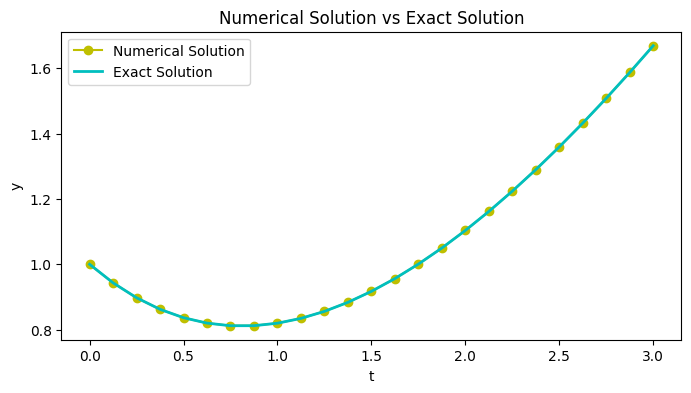

In [3]:
# Adams-Bashforth-Moulton method for solving
# y' = (t - y)/2,  y(0) = 1 on [0, 3]
import matplotlib.pyplot as plt
import numpy as np

n = 24  # N steps > 3
A = 0.0
B = 3.0

t = [0.0] * 500
y = [0.0] * 500
yy = [0.0] * 4


def f(t, y):
    # RHS function
    return (t - y) / 2.0


def exact_solution(t):
    return 3.0 * np.exp(-t / 2.0) - 2.0 + t


def rk4(t_in, yy, h1):
    for i in range(0, 3):
        t_local = h1 * i
        k0 = h1 * f(t_local, yy[i])
        k1 = h1 * f(t_local + h1 / 2.0, yy[i] + k0 / 2.0)
        k2 = h1 * f(t_local + h1 / 2.0, yy[i] + k1 / 2.0)
        k3 = h1 * f(t_local + h1, yy[i] + k2)
        yy[i + 1] = yy[i] + (1.0 / 6.0) * (k0 + 2.0 * k1 + 2.0 * k2 + k3)
        print(i, yy[i])
    return yy[3]


def ABM(a, b, N):
    h = (b - a) / N
    t[0] = a
    y[0] = 1.0

    for k in range(1, 4):
        t[k] = a + k * h

    # Compute first 3 values using RK4
    y[1] = rk4(t[1], y, h)
    y[2] = rk4(t[2], y, h)
    y[3] = rk4(t[3], y, h)

    F0 = f(t[0], y[0])
    F1 = f(t[1], y[1])
    F2 = f(t[2], y[2])
    F3 = f(t[3], y[3])

    h2 = h / 24.0

    for k in range(3, N):
        # Predictor
        p = y[k] + h2 * (-9.0 * F0 + 37.0 * F1 - 59.0 * F2 + 55.0 * F3)
        t[k + 1] = a + h * (k + 1)

        # Corrector
        F4 = f(t[k + 1], p)
        y[k + 1] = y[k] + h2 * (F1 - 5.0 * F2 + 19.0 * F3 + 9.0 * F4)

        # Update stored function values
        F0 = F1
        F1 = F2
        F2 = F3
        F3 = f(t[k + 1], y[k + 1])

    return t[: N + 1], y[: N + 1]


print("k     t       Y numerical     Y exact")
t_vals, y_vals = ABM(A, B, n)

exact_vals = []
for k in range(0, n + 1):
    y_exact = exact_solution(t_vals[k])
    exact_vals.append(y_exact)
    print("%3d %5.3f %12.11f %12.11f" % (k, t_vals[k], y_vals[k], y_exact))

plt.figure(figsize=(8, 4))
plt.title("Numerical Solution vs Exact Solution")
plt.xlabel("t")
plt.ylabel("y")

plt.plot(t_vals, y_vals, "yo-", label="Numerical Solution")
plt.plot(t_vals, exact_vals, "c-", linewidth=2, label="Exact Solution")

plt.legend()
plt.show()